In [1]:
#Trader Behavior vs Market Sentiment Analysis

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Datasets

sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

In [4]:
#Dataset Overview

print(sentiment.shape)
print(trader.shape)

(2644, 4)
(211224, 16)


In [5]:
#Data Insepection

sentiment.head()
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
#Data Information

sentiment.info()
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [7]:
# Check Missing Values

sentiment.isnull().sum()
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
#Remove Duplicates

sentiment = sentiment.drop_duplicates()
trader = trader.drop_duplicates()

In [9]:
#Convert Dates

sentiment['date'] = pd.to_datetime(sentiment['date'])
trader['date'] = pd.to_datetime(trader['Timestamp'], unit= 'ms')

In [10]:
#Align Data by Day

trader['date'] = trader['date'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [11]:
#Merge the Datasets

data = pd.merge(trader,sentiment[['date','classification']],
    on='date',
    how='left')

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed


In [12]:
#Analysis

trader_per_day = data.groupby('date').size()
print(trader_per_day)

date
2023-03-28         3
2023-11-14      1045
2024-03-09      6962
2024-07-03      7141
2024-10-27     35241
2025-02-19    133871
2025-06-15     26961
dtype: int64


In [13]:
#Average Pnl by Sentiment

pnl_sentiment = data.groupby('classification')['Closed PnL'].mean()
print(pnl_sentiment)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


In [14]:
#Long vs Short Ratio

side_ratio = data.groupby(['classification','Side']).size().unstack()
print(side_ratio)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


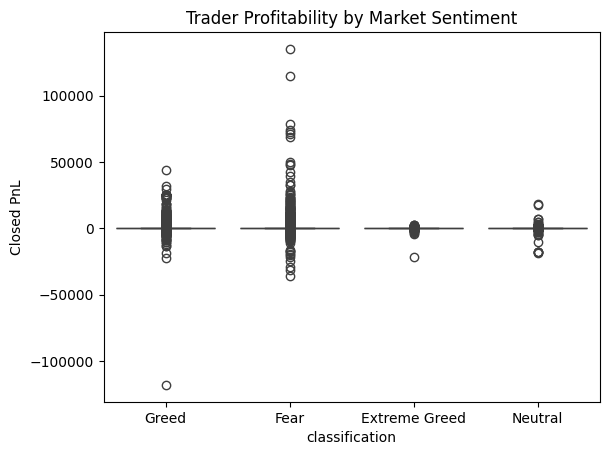

In [16]:
#pnl Visulization

sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.title("Trader Profitability by Market Sentiment")
plt.show()


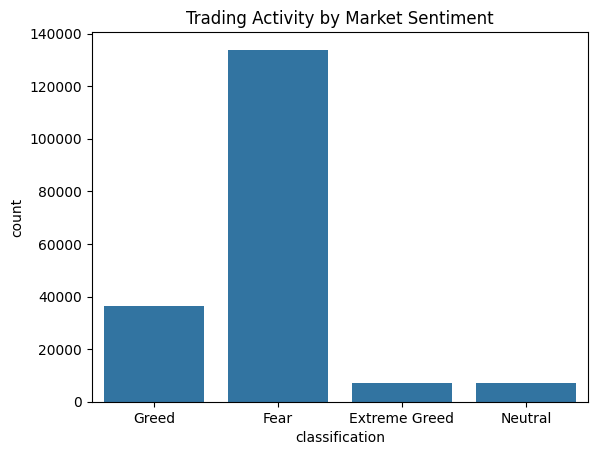

In [17]:
# Trade Count Visualization

sns.countplot(x='classification', data=data)
plt.title("Trading Activity by Market Sentiment")
plt.show()


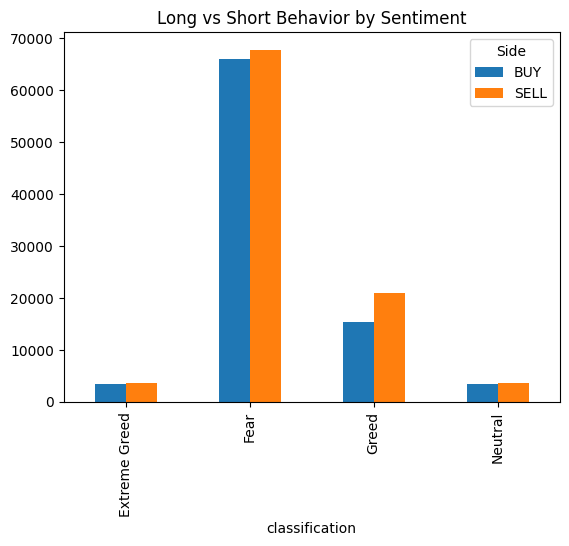

In [18]:
# Long vs Short Chart

side_ratio.plot(kind='bar')
plt.title("Long vs Short Behavior by Sentiment")
plt.show()

In [22]:
# Trade Size Segmentation


data['size_segment'] = data['Size USD'].apply(lambda x: "High" if x>10000 else "Low")
data.groupby('classification')['Size USD'].mean()



classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

In [23]:
# Frequent Traders

trade_counts = data.groupby('Account').size()

frequent_traders = trade_counts[trade_counts > 100]
print("Number of frequent traders:", len(frequent_traders))

Number of frequent traders: 32


In [25]:
# Total Profit per Trader

profit = data.groupby('Account')['Closed PnL'].sum()


In [26]:
# Average Trade Size by Sentiment

Leverage_behavior = data.groupby('classification')['Size USD'].mean()

print(Leverage_behavior)


classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


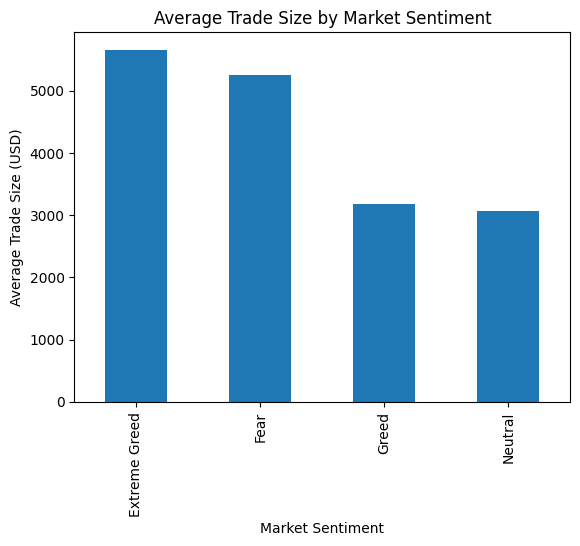

In [27]:
# Trade Size Chart

Leverage_behavior.plot(kind='bar')

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

In [28]:
# Win Rate by Sentiment

data['win'] = data['Closed PnL'] > 0

win_rate = data.groupby('classification')['win'].mean()

print(win_rate)


classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


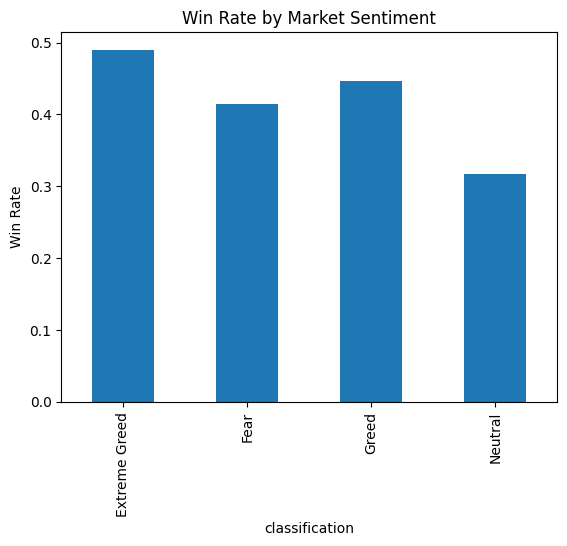

In [29]:
win_rate.plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.show()
